# Common vertebrate species across gene spectra

This compact notebook pools all vertebrate classes available in the input and reports **inclusive** intersections: a species shared by four genes is also counted in every relevant pair and triple. Presence means that a complete 12-component spectrum is available, not merely that a gene sequence exists.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start=Path.cwd()):
    """Find the repository from either its root or this analysis folder."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "1init_data" / "data" / "MutSpecVertebrates12.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root")


ROOT = find_project_root()
ANALYSIS_DIR = ROOT / "2species_intersection"
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import count_common_species as overlap

CLASS_FILTER = None  # Use an exact Class value here to analyse one class only.
MAX_COMBINATION_SIZE = 4
FIGURES_DIR = ANALYSIS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="white", context="notebook")

In [2]:
profiles = overlap.load_gene_species_profiles(
    overlap.DEFAULT_INPUT, CLASS_FILTER
)
species_by_gene = overlap.build_species_sets(profiles)
gene_summary = overlap.make_gene_summary(species_by_gene)
intersection_counts, intersection_members = overlap.count_intersections(
    species_by_gene, MAX_COMBINATION_SIZE
)

class_summary = (
    profiles[["Class", "Species"]]
    .drop_duplicates()
    .groupby("Class", as_index=False)
    .size()
    .rename(columns={"size": "n_species"})
    .sort_values("n_species", ascending=False)
)
print("Vertebrate classes represented in the input")
display(class_summary.reset_index(drop=True))
print("Usable spectra per gene")
display(gene_summary.reset_index(drop=True))
print("Inclusive intersections")
display(
    intersection_counts.sort_values(
        ["combination_size", "n_common_species", "genes"],
        ascending=[True, False, True],
    ).reset_index(drop=True).round({"jaccard_index": 3})
)

Vertebrate classes represented in the input


,Class,n_species
0,Mammalia,828
1,Actinopteri,583
2,Aves,408
3,Lepidosauria,357
4,Amphibia,150


Usable spectra per gene


,gene,n_species
0,Cytb,1697
1,ND2,850
2,CO1,206
3,CO3,113


Inclusive intersections


,combination_size,genes,n_common_species,n_union_species,jaccard_index
0,2,Cytb + ND2,249,2298,0.108
1,2,CO1 + Cytb,178,1725,0.103
2,2,CO1 + ND2,130,926,0.140
3,2,CO3 + Cytb,100,1710,0.058
4,2,CO3 + ND2,94,869,0.108
5,2,CO1 + CO3,89,230,0.387
6,3,CO1 + Cytb + ND2,122,2318,0.053
7,3,CO3 + Cytb + ND2,91,2308,0.039
8,3,CO1 + CO3 + Cytb,85,1734,0.049
9,3,CO1 + CO3 + ND2,84,940,0.089


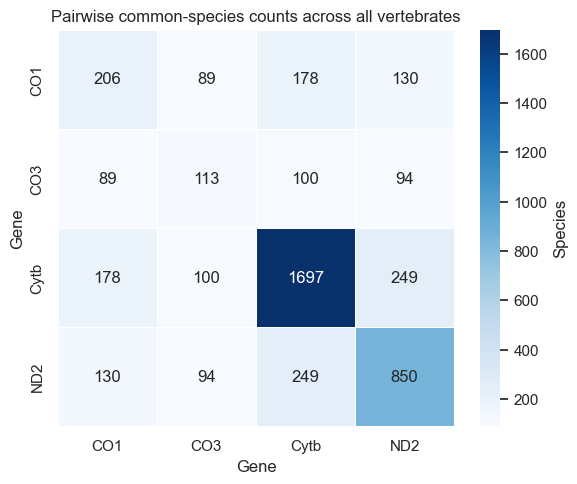

In [3]:
genes = sorted(species_by_gene)
pairwise = pd.DataFrame(index=genes, columns=genes, dtype=int)
for gene_a in genes:
    for gene_b in genes:
        pairwise.loc[gene_a, gene_b] = len(
            species_by_gene[gene_a] & species_by_gene[gene_b]
        )

fig, ax = plt.subplots(figsize=(6.2, 5.0))
sns.heatmap(
    pairwise.astype(int), annot=True, fmt="d", cmap="Blues",
    square=True, linewidths=0.5, cbar_kws={"label": "Species"}, ax=ax,
)
ax.set_title("Pairwise common-species counts across all vertebrates")
ax.set(xlabel="Gene", ylabel="Gene")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "pairwise_common_species_counts.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

In [4]:
def common_count(*genes):
    if not set(genes).issubset(species_by_gene):
        return None
    return len(set.intersection(*(species_by_gene[g] for g in genes)))

requested_comparisons = pd.DataFrame(
    [
        {"genes": "CO3 + ND6", "n_common_species": common_count("CO3", "ND6"),
         "note": "ND6 has no spectrum in the 12-component input"},
        {"genes": "CO1 + Cytb", "n_common_species": common_count("CO1", "Cytb"),
         "note": "Available requested comparison"},
        {"genes": "CO3 + ND2", "n_common_species": common_count("CO3", "ND2"),
         "note": "Diagnostic only; ND2 is not ND6"},
        {"genes": "CO1 + CO3 + Cytb", "n_common_species": common_count("CO1", "CO3", "Cytb"),
         "note": "Matched cohort used for the TSSS notebook"},
    ]
)
display(requested_comparisons)

,genes,n_common_species,note
0,CO3 + ND6,NaN,ND6 has no spectrum in the 12-component input
1,CO1 + Cytb,178.0,Available requested comparison
2,CO3 + ND2,94.0,Diagnostic only; ND2 is not ND6
3,CO1 + CO3 + Cytb,85.0,Matched cohort used for the TSSS notebook
